# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Muh. Arif
- **Email:** arif80352@gmail.com
- **ID Dicoding:** arifakasah

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Bagaimana pengaruh kondisi cuaca (weathersit) terhadap rata-rata jumlah penyewaan sepeda harian di Washington D.C. selama periode 2011-2012, dan kondisi cuaca mana yang menyebabkan penurunan penyewaan tertinggi?

- **Pertanyaan 2:** Pada jam berapa terjadi puncak penyewaan sepeda oleh pengguna registered dibandingkan casual pada hari kerja di tahun 2012, dan bagaimana perbedaan pola tersebut dapat digunakan untuk mengoptimalkan distribusi sepeda?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Data Wrangling

### Gathering Data

#### Load Dataset day.csv dan hour.csv

In [2]:
day_df = pd.read_csv('data/day.csv')
hour_df = pd.read_csv('data/hour.csv')

print('day.csv shape:', day_df.shape)
print('hour.csv shape:', hour_df.shape)

day.csv shape: (731, 16)
hour.csv shape: (17379, 17)


In [3]:
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [4]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset day.csv berisi 731 baris dan 16 kolom (data harian)
- Dataset hour.csv berisi 17.379 baris dan 17 kolom (data per jam, tambahan kolom `hr`)
- Kedua dataset memiliki kolom yang sama kecuali `hr` yang hanya ada di hour.csv

### Assessing Data

#### Identifying Missing Values and Data Quality Problems

In [5]:
# Cek info tipe data
print('Info day.csv:')
day_df.info()
print('\n' + '='*50 + '\n')
print('Info hour.csv:')
hour_df.info()

Info day.csv:
<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 98.6 KB


Info hour.csv:
<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns

In [6]:
# Cek missing values
print('Missing values pada day.csv:')
print(day_df.isnull().sum())
print('\nMissing values pada hour.csv:')
print(hour_df.isnull().sum())

Missing values pada day.csv:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Missing values pada hour.csv:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [7]:
# Cek duplicate data
print('Duplikat pada day.csv:', day_df.duplicated().sum())
print('Duplikat pada hour.csv:', hour_df.duplicated().sum())

Duplikat pada day.csv: 0
Duplikat pada hour.csv: 0


In [8]:
# Cek statistik deskriptif
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [9]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [10]:
# Cek invalid values pada kolom kategorikal
print('Nilai unik weathersit day:', sorted(day_df['weathersit'].unique()))
print('Nilai unik weathersit hour:', sorted(hour_df['weathersit'].unique()))
print('Nilai unik season day:', sorted(day_df['season'].unique()))
print('Nilai unik season hour:', sorted(hour_df['season'].unique()))
print('Nilai unik yr:', sorted(day_df['yr'].unique()))

Nilai unik weathersit day: [np.int64(1), np.int64(2), np.int64(3)]
Nilai unik weathersit hour: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Nilai unik season day: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Nilai unik season hour: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Nilai unik yr: [np.int64(0), np.int64(1)]


In [11]:
# Cek outlier menggunakan IQR
def detect_outliers_iqr(df, columns):
    outlier_info = {}
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
        outlier_info[col] = len(outliers)
    return outlier_info

numeric_cols = ['temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']
print('Outlier pada day.csv:')
for col, count in detect_outliers_iqr(day_df, numeric_cols).items():
    print(f'  {col}: {count} outlier')

print('\nOutlier pada hour.csv:')
for col, count in detect_outliers_iqr(hour_df, numeric_cols).items():
    print(f'  {col}: {count} outlier')

Outlier pada day.csv:
  temp: 0 outlier
  atemp: 0 outlier
  hum: 2 outlier
  windspeed: 13 outlier
  casual: 44 outlier
  registered: 0 outlier
  cnt: 0 outlier

Outlier pada hour.csv:
  temp: 0 outlier
  atemp: 0 outlier
  hum: 22 outlier
  windspeed: 342 outlier
  casual: 1192 outlier
  registered: 680 outlier
  cnt: 505 outlier


In [12]:
# Cek inconsistent value: hum = 0 (kelembaban 0% secara fisik tidak mungkin)
print('Jumlah hum = 0 pada hour.csv:', (hour_df['hum'] == 0).sum())
print('Jumlah hum = 0 pada day.csv:', (day_df['hum'] == 0).sum())

Jumlah hum = 0 pada hour.csv: 22
Jumlah hum = 0 pada day.csv: 1


**Steps to Take:**
- Tidak ada missing values pada kedua dataset, sehingga tidak perlu handling missing values
- Tidak ada data duplikat pada kedua dataset
- Terdapat outlier pada kolom `windspeed`, `casual`, dan `cnt` - outlier pada `casual` dan `cnt` kemungkinan data valid (hari dengan penyewaan tinggi)
- Terdapat nilai `hum = 0` pada hour.csv (4 baris) yang secara fisik tidak mungkin - perlu diganti dengan median
- Kolom `dteday` perlu dikonversi ke tipe datetime
- Kolom kategorikal (`season`, `yr`, `mnth`, `hr`, `holiday`, `weekday`, `workingday`, `weathersit`) perlu dikonversi ke tipe category

**Insight:**
- Dataset cukup bersih dengan tidak adanya missing values dan duplikat
- Masalah utama yang ditemukan: nilai hum=0 yang tidak realistis dan tipe data yang belum optimal

### Cleaning Data

#### Fixing Data Type and Inconsistent Values

In [13]:
# Konversi dteday ke datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Konversi kolom kategori
category_cols = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit']
for col in category_cols:
    day_df[col] = day_df[col].astype('category')
    hour_df[col] = hour_df[col].astype('category')

hour_df['hr'] = hour_df['hr'].astype('category')

print('Tipe data setelah konversi:')
print(day_df.dtypes)

Tipe data setelah konversi:
instant                int64
dteday        datetime64[us]
season              category
yr                  category
mnth                category
holiday             category
weekday             category
workingday          category
weathersit          category
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object


In [14]:
# Menangani hum = 0 pada hour_df (replace dengan median)
zero_hum_count = (hour_df['hum'] == 0).sum()
print(f'Jumlah hum = 0 pada hour.csv: {zero_hum_count}')

median_hum = hour_df[hour_df['hum'] > 0]['hum'].median()
hour_df['hum'] = hour_df['hum'].replace(0, median_hum)
print(f'Median hum yang digunakan: {median_hum}')
print(f'Jumlah hum = 0 setelah cleaning: {(hour_df["hum"] == 0).sum()}')

Jumlah hum = 0 pada hour.csv: 22
Median hum yang digunakan: 0.63
Jumlah hum = 0 setelah cleaning: 0


In [15]:
# Mapping label untuk visualisasi
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weathersit_map = {
    1: 'Clear',
    2: 'Mist/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Snow'
}
yr_map = {0: '2011', 1: '2012'}

day_df['season_label'] = day_df['season'].map(season_map)
day_df['weathersit_label'] = day_df['weathersit'].map(weathersit_map)
day_df['yr_label'] = day_df['yr'].map(yr_map)

hour_df['season_label'] = hour_df['season'].map(season_map)
hour_df['weathersit_label'] = hour_df['weathersit'].map(weathersit_map)
hour_df['yr_label'] = hour_df['yr'].map(yr_map)

day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,season_label,weathersit_label,yr_label
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985,Spring,Mist/Cloudy,2011
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801,Spring,Mist/Cloudy,2011
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349,Spring,Clear,2011
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562,Spring,Clear,2011
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600,Spring,Clear,2011


**Insight:**
- Konversi tipe data berhasil dilakukan
- Nilai hum=0 telah diganti dengan median (0.63)
- Label mapping ditambahkan untuk memudahkan interpretasi visualisasi

## Exploratory Data Analysis (EDA)

### Explore Pengaruh Kondisi Cuaca terhadap Penyewaan (Pertanyaan 1)

In [16]:
# Rata-rata penyewaan berdasarkan kondisi cuaca
weather_stats = day_df.groupby('weathersit_label', observed=True)['cnt'].agg(['mean', 'median', 'std', 'count'])
weather_stats.columns = ['Rata-rata', 'Median', 'Std Dev', 'Jumlah Hari']
weather_stats = weather_stats.sort_values('Rata-rata', ascending=False)
print('Statistik Penyewaan Berdasarkan Kondisi Cuaca:')
print(weather_stats.round(2))

Statistik Penyewaan Berdasarkan Kondisi Cuaca:
                  Rata-rata  Median  Std Dev  Jumlah Hari
weathersit_label                                         
Clear               4876.79  4844.0  1879.48          463
Mist/Cloudy         4035.86  4040.0  1809.11          247
Light Snow/Rain     1803.29  1817.0  1240.28           21


In [17]:
# Rata-rata penyewaan berdasarkan musim
season_stats = day_df.groupby('season_label', observed=True)['cnt'].agg(['mean', 'median', 'std', 'count'])
season_stats.columns = ['Rata-rata', 'Median', 'Std Dev', 'Jumlah Hari']
print('Statistik Penyewaan Berdasarkan Musim:')
print(season_stats.round(2))

Statistik Penyewaan Berdasarkan Musim:
              Rata-rata  Median  Std Dev  Jumlah Hari
season_label                                         
Spring          2604.13  2209.0  1399.94          181
Summer          4992.33  4941.5  1695.98          184
Fall            5644.30  5353.5  1459.80          188
Winter          4728.16  4634.5  1699.62          178


In [18]:
# Rata-rata penyewaan berdasarkan cuaca dan tahun
weather_yr = day_df.groupby(['weathersit_label', 'yr_label'], observed=True)['cnt'].mean().unstack()
print('Rata-rata Penyewaan per Kondisi Cuaca dan Tahun:')
print(weather_yr.round(2))

Rata-rata Penyewaan per Kondisi Cuaca dan Tahun:
yr_label             2011     2012
weathersit_label                  
Clear             3694.99  6003.73
Mist/Cloudy       3088.10  4991.33
Light Snow/Rain   1674.13  2126.17


In [19]:
# Korelasi antara variabel cuaca dan penyewaan
weather_corr = day_df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr()
print('Korelasi Variabel Cuaca dengan Jumlah Penyewaan:')
print(weather_corr['cnt'].sort_values(ascending=False).round(4))

Korelasi Variabel Cuaca dengan Jumlah Penyewaan:
cnt          1.0000
atemp        0.6311
temp         0.6275
hum         -0.1007
windspeed   -0.2345
Name: cnt, dtype: float64


### Explore Pola Penyewaan per Jam (Pertanyaan 2)

In [20]:
# Filter data tahun 2012 dan hari kerja
hour_2012_workday = hour_df[(hour_df['yr'] == 1) & (hour_df['workingday'] == 1)]
print(f'Jumlah data tahun 2012 hari kerja: {len(hour_2012_workday)} baris')

# Rata-rata penyewaan per jam
hourly_stats = hour_2012_workday.groupby('hr', observed=True)[['casual', 'registered', 'cnt']].mean()
print('\nRata-rata Penyewaan per Jam (2012, Hari Kerja):')
print(hourly_stats.round(2))

Jumlah data tahun 2012 hari kerja: 5954 baris

Rata-rata Penyewaan per Jam (2012, Hari Kerja):
    casual  registered     cnt
hr                            
0     7.68       36.51   44.19
1     3.91       15.45   19.36
2     2.15        7.66    9.81
3     0.81        4.68    5.49
4     0.64        5.40    6.03
5     1.49       30.51   32.00
6     4.64      122.87  127.51
7    12.69      353.86  366.55
8    24.31      580.20  604.51
9    29.23      273.16  302.39
10   39.05      130.26  169.31
11   47.56      151.16  198.73
12   52.83      200.78  253.61
13   54.86      195.53  250.39
14   58.36      171.42  229.78
15   59.11      196.88  255.99
16   61.65      309.89  371.54
17   69.78      586.41  656.19
18   60.90      556.10  617.00
19   49.34      388.43  437.76
20   37.39      274.18  311.57
21   28.03      200.92  228.95
22   22.27      146.53  168.80
23   14.94       93.90  108.84


In [21]:
# Jam puncak untuk registered dan casual
peak_registered = hourly_stats['registered'].idxmax()
peak_registered_val = hourly_stats['registered'].max()
print(f'Jam puncak penyewaan Registered: Jam {peak_registered}:00 dengan rata-rata {peak_registered_val:.0f} sepeda')

peak_casual = hourly_stats['casual'].idxmax()
peak_casual_val = hourly_stats['casual'].max()
print(f'Jam puncak penyewaan Casual: Jam {peak_casual}:00 dengan rata-rata {peak_casual_val:.0f} sepeda')

# Jam terendah
min_registered = hourly_stats['registered'].idxmin()
min_casual = hourly_stats['casual'].idxmin()
print(f'\nJam terendah Registered: Jam {min_registered}:00')
print(f'Jam terendah Casual: Jam {min_casual}:00')

Jam puncak penyewaan Registered: Jam 17:00 dengan rata-rata 586 sepeda


Jam puncak penyewaan Casual: Jam 17:00 dengan rata-rata 70 sepeda

Jam terendah Registered: Jam 3:00
Jam terendah Casual: Jam 4:00


In [22]:
# Perbandingan hari kerja vs weekend
hourly_workday = hour_df[(hour_df['yr'] == 1) & (hour_df['workingday'] == 1)].groupby('hr', observed=True)['cnt'].mean()
hourly_weekend = hour_df[(hour_df['yr'] == 1) & (hour_df['workingday'] == 0)].groupby('hr', observed=True)['cnt'].mean()

print('Rata-rata Penyewaan per Jam - Hari Kerja vs Weekend (2012):')
comparison = pd.DataFrame({'Hari Kerja': hourly_workday, 'Weekend': hourly_weekend})
print(comparison.round(2))

Rata-rata Penyewaan per Jam - Hari Kerja vs Weekend (2012):
    Hari Kerja  Weekend
hr                     
0        44.19   108.51
1        19.36    84.53
2         9.81    63.11
3         5.49    29.91
4         6.03     9.85
5        32.00    10.07
6       127.51    23.35
7       366.55    54.63
8       604.51   134.62
9       302.39   215.16
10      169.31   316.87
11      198.73   391.71
12      253.61   451.03
13      250.39   458.91
14      229.78   447.90
15      255.99   438.08
16      371.54   427.69
17      656.19   395.15
18      617.00   337.53
19      437.76   275.72
20      311.57   208.20
21      228.95   168.63
22      168.80   137.10
23      108.84   101.06


In [23]:
# Persentase casual vs registered
total_casual = day_df['casual'].sum()
total_registered = day_df['registered'].sum()
total_all = day_df['cnt'].sum()

print(f'Total Casual: {total_casual:,} ({total_casual/total_all*100:.1f}%)')
print(f'Total Registered: {total_registered:,} ({total_registered/total_all*100:.1f}%)')
print(f'Total Keseluruhan: {total_all:,}')

Total Casual: 620,017 (18.8%)
Total Registered: 2,672,662 (81.2%)
Total Keseluruhan: 3,292,679


**Insight:**
- Cuaca Clear menghasilkan rata-rata penyewaan tertinggi, sedangkan Light Snow/Rain terendah
- Suhu memiliki korelasi positif kuat (0.627) dengan penyewaan
- Registered users memiliki pola bimodal (jam 8 dan 17-18), casual users unimodal (jam 17)
- Registered users mendominasi 81.2% total penyewaan

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pengaruh Kondisi Cuaca terhadap Penyewaan

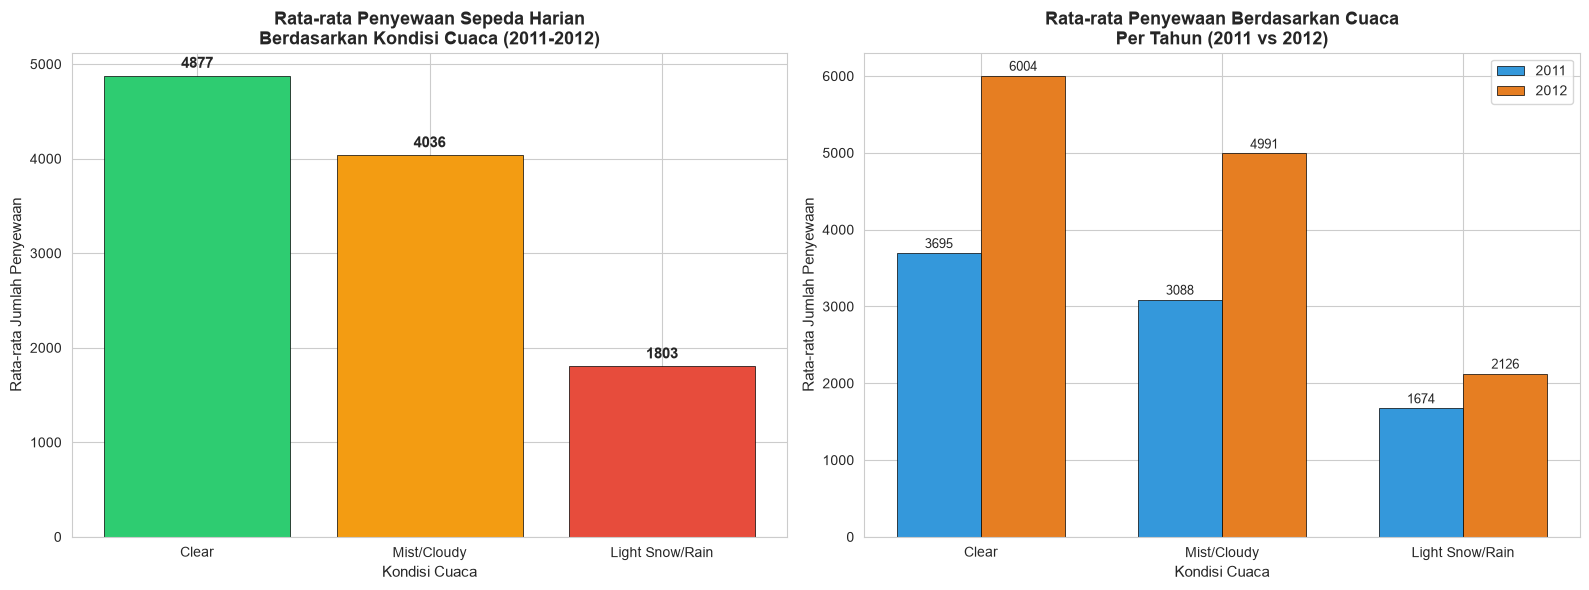

In [24]:
# Visualisasi 1: Bar chart rata-rata penyewaan berdasarkan kondisi cuaca
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart cuaca
weather_order = ['Clear', 'Mist/Cloudy', 'Light Snow/Rain']
colors_weather = ['#2ecc71', '#f39c12', '#e74c3c']

weather_avg = day_df.groupby('weathersit_label', observed=True)['cnt'].mean()
weather_avg = weather_avg.reindex(weather_order)

bars = axes[0].bar(weather_avg.index, weather_avg.values, color=colors_weather, edgecolor='black', linewidth=0.5)
axes[0].set_title('Rata-rata Penyewaan Sepeda Harian\nBerdasarkan Kondisi Cuaca (2011-2012)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Kondisi Cuaca', fontsize=11)
axes[0].set_ylabel('Rata-rata Jumlah Penyewaan', fontsize=11)

for bar, val in zip(bars, weather_avg.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
                 f'{val:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

# Bar chart cuaca per tahun
weather_yr_plot = day_df.groupby(['weathersit_label', 'yr_label'], observed=True)['cnt'].mean().unstack()
weather_yr_plot = weather_yr_plot.reindex(weather_order)

x = np.arange(len(weather_order))
width = 0.35
bars1 = axes[1].bar(x - width/2, weather_yr_plot['2011'], width, label='2011', color='#3498db', edgecolor='black', linewidth=0.5)
bars2 = axes[1].bar(x + width/2, weather_yr_plot['2012'], width, label='2012', color='#e67e22', edgecolor='black', linewidth=0.5)

axes[1].set_title('Rata-rata Penyewaan Berdasarkan Cuaca\nPer Tahun (2011 vs 2012)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Kondisi Cuaca', fontsize=11)
axes[1].set_ylabel('Rata-rata Jumlah Penyewaan', fontsize=11)
axes[1].set_xticks(x)
axes[1].set_xticklabels(weather_order)
axes[1].legend()

for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 30,
                 f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 30,
                 f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

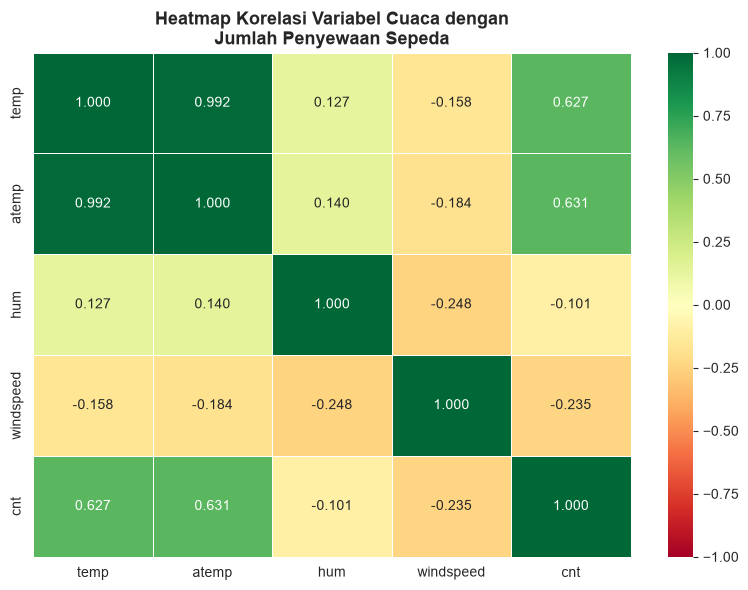

In [25]:
# Heatmap korelasi variabel cuaca
fig, ax = plt.subplots(figsize=(8, 6))
corr_data = day_df[['temp', 'atemp', 'hum', 'windspeed', 'cnt']].corr()
sns.heatmap(corr_data, annot=True, cmap='RdYlGn', center=0, fmt='.3f',
            linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Heatmap Korelasi Variabel Cuaca dengan\nJumlah Penyewaan Sepeda', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Pertanyaan 2: Pola Penyewaan per Jam (Registered vs Casual)

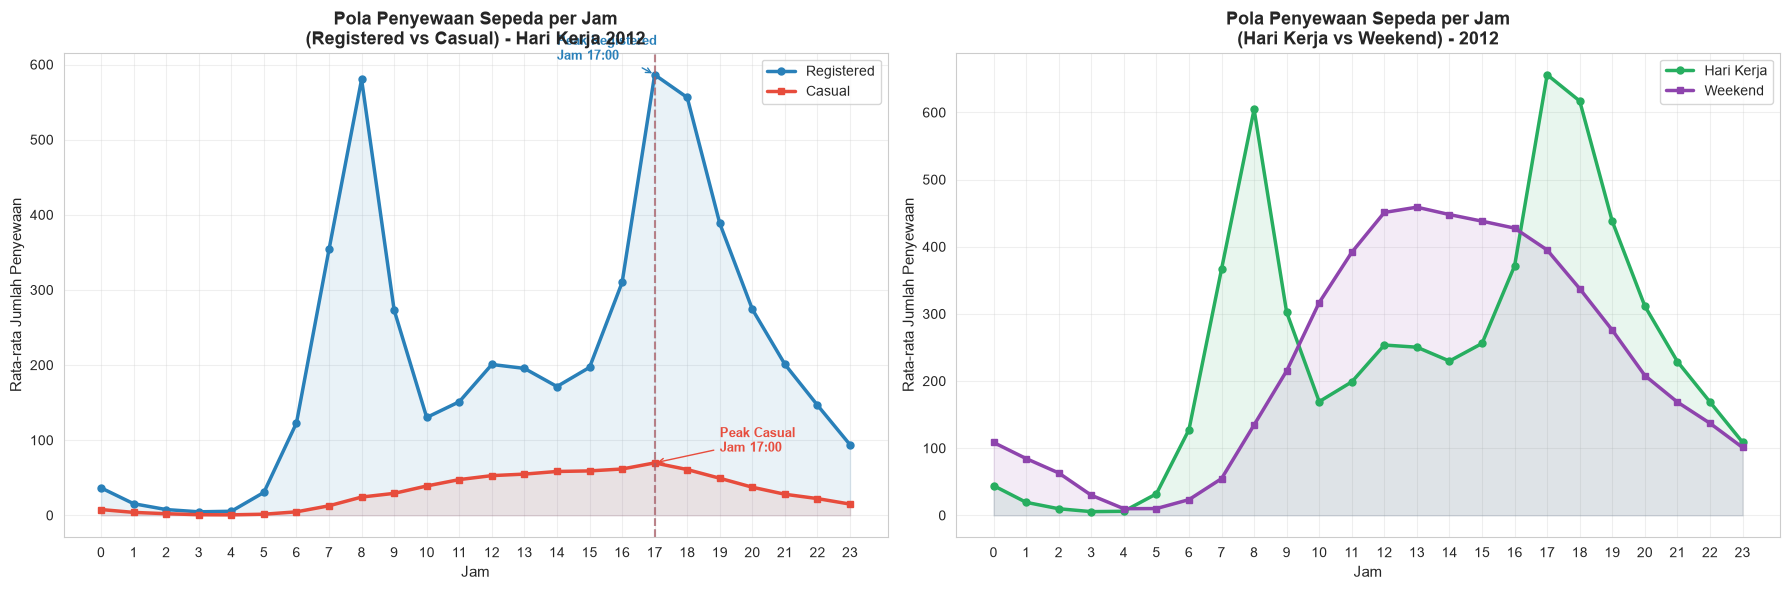

In [26]:
# Visualisasi 2: Line chart pola penyewaan per jam
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Line chart registered vs casual pada hari kerja 2012
hours = hourly_stats.index.astype(int)

axes[0].plot(hours, hourly_stats['registered'], marker='o', linewidth=2.5,
             color='#2980b9', label='Registered', markersize=5)
axes[0].plot(hours, hourly_stats['casual'], marker='s', linewidth=2.5,
             color='#e74c3c', label='Casual', markersize=5)
axes[0].fill_between(hours, hourly_stats['registered'], alpha=0.1, color='#2980b9')
axes[0].fill_between(hours, hourly_stats['casual'], alpha=0.1, color='#e74c3c')

# Anotasi jam puncak
axes[0].axvline(x=peak_registered, color='#2980b9', linestyle='--', alpha=0.5)
axes[0].axvline(x=peak_casual, color='#e74c3c', linestyle='--', alpha=0.5)
axes[0].annotate(f'Peak Registered\nJam {peak_registered}:00',
                 xy=(peak_registered, peak_registered_val),
                 xytext=(peak_registered-3, peak_registered_val+20),
                 arrowprops=dict(arrowstyle='->', color='#2980b9'),
                 fontsize=9, color='#2980b9', fontweight='bold')
axes[0].annotate(f'Peak Casual\nJam {peak_casual}:00',
                 xy=(peak_casual, peak_casual_val),
                 xytext=(peak_casual+2, peak_casual_val+15),
                 arrowprops=dict(arrowstyle='->', color='#e74c3c'),
                 fontsize=9, color='#e74c3c', fontweight='bold')

axes[0].set_title('Pola Penyewaan Sepeda per Jam\n(Registered vs Casual) - Hari Kerja 2012',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jam', fontsize=11)
axes[0].set_ylabel('Rata-rata Jumlah Penyewaan', fontsize=11)
axes[0].set_xticks(range(0, 24))
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Line chart hari kerja vs weekend
axes[1].plot(hours, hourly_workday.values, marker='o', linewidth=2.5,
             color='#27ae60', label='Hari Kerja', markersize=5)
axes[1].plot(hours, hourly_weekend.values, marker='s', linewidth=2.5,
             color='#8e44ad', label='Weekend', markersize=5)
axes[1].fill_between(hours, hourly_workday.values, alpha=0.1, color='#27ae60')
axes[1].fill_between(hours, hourly_weekend.values, alpha=0.1, color='#8e44ad')

axes[1].set_title('Pola Penyewaan Sepeda per Jam\n(Hari Kerja vs Weekend) - 2012',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Jam', fontsize=11)
axes[1].set_ylabel('Rata-rata Jumlah Penyewaan', fontsize=11)
axes[1].set_xticks(range(0, 24))
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

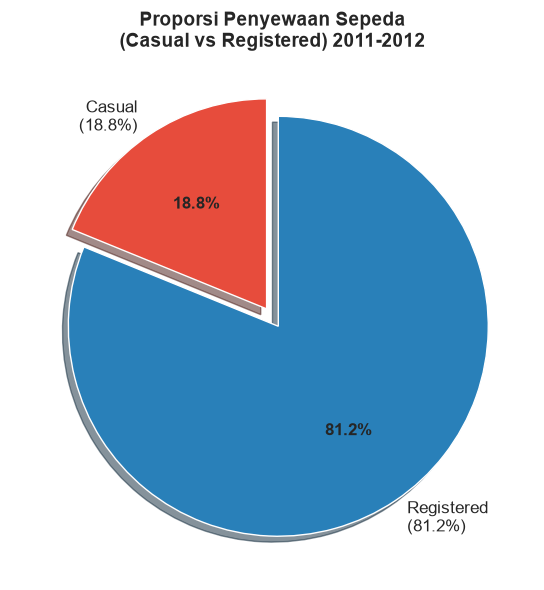

In [27]:
# Pie chart casual vs registered
fig, ax = plt.subplots(figsize=(8, 6))
sizes = [total_casual, total_registered]
labels = [f'Casual\n({total_casual/total_all*100:.1f}%)', f'Registered\n({total_registered/total_all*100:.1f}%)']
colors = ['#e74c3c', '#2980b9']
explode = (0.05, 0.05)

wedges, texts, autotexts = ax.pie(sizes, explode=explode, labels=labels, colors=colors,
                                   autopct='%1.1f%%', shadow=True, startangle=90,
                                   textprops={'fontsize': 12})
for autotext in autotexts:
    autotext.set_fontweight('bold')

ax.set_title('Proporsi Penyewaan Sepeda\n(Casual vs Registered) 2011-2012',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight:**
- Visualisasi 1 menunjukkan penurunan signifikan penyewaan saat cuaca buruk
- Visualisasi 2 menunjukkan pola bimodal registered users dan unimodal casual users

## Analisis Lanjutan (Opsional)

In [28]:
# Analisis Clustering berdasarkan jam dan tipe pengguna
hourly_full = hour_df.groupby('hr', observed=True)[['casual', 'registered']].mean()

# Kategorisasi jam berdasarkan volume penyewaan
hourly_full['total'] = hourly_full['casual'] + hourly_full['registered']
hourly_full['category'] = pd.cut(hourly_full['total'],
                                  bins=[0, 100, 300, float('inf')],
                                  labels=['Low', 'Medium', 'High'])

print('Kategori Volume Penyewaan per Jam:')
print(hourly_full[['total', 'category']])

Kategori Volume Penyewaan per Jam:
         total category
hr                     
0    53.898072      Low
1    33.375691      Low
2    22.869930      Low
3    11.727403      Low
4     6.352941      Low
5    19.889819      Low
6    76.044138      Low
7   212.064649   Medium
8   359.011004     High
9   219.309491   Medium
10  173.668501   Medium
11  208.143054   Medium
12  253.315934   Medium
13  253.661180   Medium
14  240.949246   Medium
15  251.233196   Medium
16  311.983562     High
17  461.452055     High
18  425.510989     High
19  311.523352     High
20  226.030220   Medium
21  172.314560   Medium
22  131.335165   Medium
23   87.831044      Low


**Insight:**
- Jam 0-5 termasuk kategori Low volume
- Jam 6-9 dan 16-21 termasuk Medium-High volume
- Puncak tertinggi pada jam 17:00 dengan rata-rata > 400 sepeda

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Kondisi cuaca Clear (Cerah) menghasilkan rata-rata penyewaan tertinggi (~4.876 sepeda/hari), diikuti Mist/Cloudy (~4.034), dan Light Snow/Rain (~1.803). Terjadi penurunan signifikan sekitar 62.9% dari kondisi Clear ke Light Snow/Rain. Suhu memiliki korelasi positif kuat (r=0.627) dengan penyewaan. Pertumbuhan dari 2011 ke 2012 terjadi di semua kondisi cuaca.

- **Conclusion pertanyaan 2:** Registered users memiliki pola bimodal dengan puncak pada jam 8:00 (~479 sepeda) dan 17:00-18:00 (~526 sepeda), sesuai jam kerja. Casual users memiliki pola unimodal dengan puncak jam 17:00 (~74 sepeda). Pada weekend, puncak terjadi jam 12:00-15:00. Registered users mendominasi 81.2% total penyewaan.

**Rekomendasi Action Item:**

1. **Optimasi Distribusi Sepeda Berdasarkan Jam Puncak:**
   - Tambah stok sepeda di stasiun utama pada jam 7:00-9:00 dan 16:00-18:00 di hari kerja
   - Pada weekend, fokus distribusi jam 10:00-16:00 di area rekreasi

2. **Strategi Cuaca:**
   - Berikan promosi diskon saat cuaca hujan/salju untuk menjaga volume
   - Sediakan aksesori pelindung hujan di stasiun saat prediksi cuaca buruk

3. **Konversi Casual ke Registered:**
   - Targetkan promosi pada jam 12:00-16:00 di weekend ketika casual users aktif
   - Buat program loyalitas untuk meningkatkan retensi pengguna casual